# 07 Deep Learning Models for Building Energy Load Prediction

This notebook evaluates deep learning models for predicting **Heating Load** and **Cooling Load** using the same saved train-test split used in the previous modeling notebooks.

Although the dataset is relatively small for deep learning, neural network models are included to provide a complete modeling comparison across classical statistics, regularized regression, semi-parametric models, nonlinear machine learning, and deep learning.

## Notebook Objectives

This notebook will:

1. Load the saved training and testing datasets from `data/modeling`.
2. Preprocess numeric and categorical predictors.
3. Fit several neural network architectures:
   - Simple ANN
   - Deeper ANN
   - Regularized ANN with Dropout and L2 regularization
4. Use early stopping to reduce overfitting.
5. Evaluate performance using \(R^2\), Adjusted \(R^2\), RMSE, MAE, and train-test gap.
6. Plot learning curves and actual-versus-predicted results.
7. Save the deep learning results for final model comparison.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [2]:
# ============================================================
# 2. IMPORT TENSORFLOW / KERAS
# ============================================================

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l2

    tf.random.set_seed(RANDOM_STATE)
    print("TensorFlow version:", tf.__version__)

except ImportError as e:
    raise ImportError(
        "TensorFlow is not installed in this environment. "
        "Install it using: pip install tensorflow"
    )

TensorFlow version: 2.21.0


In [3]:
# ============================================================
# 3. LOAD SAVED TRAINING AND TESTING DATASETS
# ============================================================

DATA_DIR = Path("../data/modeling")

if not DATA_DIR.exists():
    DATA_DIR = Path("data/modeling")

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_heat_train = pd.read_csv(DATA_DIR / "y_heat_train.csv")["heating_load"]
y_heat_test = pd.read_csv(DATA_DIR / "y_heat_test.csv")["heating_load"]

y_cool_train = pd.read_csv(DATA_DIR / "y_cool_train.csv")["cooling_load"]
y_cool_test = pd.read_csv(DATA_DIR / "y_cool_test.csv")["cooling_load"]

print("Data directory:", DATA_DIR.resolve())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Heating target:", y_heat_train.shape, y_heat_test.shape)
print("Cooling target:", y_cool_train.shape, y_cool_test.shape)

display(X_train.head())

Data directory: C:\Users\admin\Desktop\pppp lab\group-work\data\modeling
X_train shape: (614, 8)
X_test shape: (154, 8)
Heating target: (614,) (154,)
Cooling target: (614,) (154,)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.820000,612.500000,318.500000,147.000000,7.000000,2,0.100000,1
1,0.640000,784.000000,343.000000,220.500000,3.500000,4,0.400000,2
2,0.860000,588.000000,294.000000,147.000000,7.000000,4,0.250000,2
3,0.900000,563.500000,318.500000,122.500000,7.000000,4,0.250000,1
4,0.660000,759.500000,318.500000,220.500000,3.500000,5,0.100000,4


In [4]:
# ============================================================
# 4. DEFINE NUMERIC AND CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "orientation",
    "glazing_area_distribution"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area']

Categorical features:
['orientation', 'glazing_area_distribution']


## Deep Learning Preprocessing

Neural networks require numerical inputs on a comparable scale. Therefore, numeric predictors are standardized and categorical predictors are one-hot encoded.

In [5]:
# ============================================================
# 5. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = np.asarray(X_train_processed).astype("float32")
X_test_processed = np.asarray(X_test_processed).astype("float32")

y_heat_train_np = y_heat_train.to_numpy().astype("float32")
y_heat_test_np = y_heat_test.to_numpy().astype("float32")

y_cool_train_np = y_cool_train.to_numpy().astype("float32")
y_cool_test_np = y_cool_test.to_numpy().astype("float32")

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (614, 14)
Processed X_test shape: (154, 14)


In [6]:
# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_predictions(y_train, train_pred, y_test, test_pred, target_name, model_name, n_features):
    n_test = len(y_test)
    test_r2 = r2_score(y_test, test_pred)

    adjusted_r2 = 1 - ((1 - test_r2) * (n_test - 1) / (n_test - n_features - 1))

    results = pd.DataFrame({
        "Target": [target_name],
        "Model": [model_name],
        "Train_R2": [r2_score(y_train, train_pred)],
        "Test_R2": [test_r2],
        "Test_Adjusted_R2": [adjusted_r2],
        "Test_RMSE": [np.sqrt(mean_squared_error(y_test, test_pred))],
        "Test_MAE": [mean_absolute_error(y_test, test_pred)],
        "Train_Test_R2_Gap": [r2_score(y_train, train_pred) - test_r2]
    })

    return results

In [7]:
# ============================================================
# 7. MODEL-BUILDING FUNCTIONS
# ============================================================

def build_simple_ann(input_dim):
    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_deeper_ann(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_regularized_ann(input_dim):
    model = Sequential([
        Dense(64, activation="relu", kernel_regularizer=l2(0.001), input_shape=(input_dim,)),
        Dropout(0.15),
        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.15),
        Dense(16, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [8]:
# ============================================================
# 8. CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=60,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=25,
    min_lr=1e-6
)

In [9]:
# ============================================================
# 9. TRAINING FUNCTION
# ============================================================

def train_deep_learning_model(build_fn, X_train, y_train, X_test, y_test, target_name, model_name):
    input_dim = X_train.shape[1]

    model = build_fn(input_dim)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=1000,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )

    train_pred = model.predict(X_train, verbose=0).flatten()
    test_pred = model.predict(X_test, verbose=0).flatten()

    results = evaluate_predictions(
        y_train,
        train_pred,
        y_test,
        test_pred,
        target_name=target_name,
        model_name=model_name,
        n_features=X_train.shape[1]
    )

    return model, history, results, train_pred, test_pred

# Deep Learning Model Training

Each architecture is trained separately for Heating Load and Cooling Load. Early stopping is used to prevent unnecessary training and reduce overfitting.

In [10]:
# ============================================================
# 10. TRAIN ALL DEEP LEARNING MODELS
# ============================================================

architectures = {
    "Simple ANN": build_simple_ann,
    "Deeper ANN": build_deeper_ann,
    "Regularized ANN": build_regularized_ann
}

dl_results_list = []
trained_models = {}
histories = {}
predictions = {}

for arch_name, build_fn in architectures.items():

    # Heating Load
    heat_model, heat_history, heat_results, heat_train_pred, heat_test_pred = train_deep_learning_model(
        build_fn,
        X_train_processed,
        y_heat_train_np,
        X_test_processed,
        y_heat_test_np,
        target_name="Heating Load",
        model_name=arch_name
    )

    dl_results_list.append(heat_results)
    trained_models[f"Heating Load - {arch_name}"] = heat_model
    histories[f"Heating Load - {arch_name}"] = heat_history
    predictions[f"Heating Load - {arch_name}"] = (heat_train_pred, heat_test_pred)

    # Cooling Load
    cool_model, cool_history, cool_results, cool_train_pred, cool_test_pred = train_deep_learning_model(
        build_fn,
        X_train_processed,
        y_cool_train_np,
        X_test_processed,
        y_cool_test_np,
        target_name="Cooling Load",
        model_name=arch_name
    )

    dl_results_list.append(cool_results)
    trained_models[f"Cooling Load - {arch_name}"] = cool_model
    histories[f"Cooling Load - {arch_name}"] = cool_history
    predictions[f"Cooling Load - {arch_name}"] = (cool_train_pred, cool_test_pred)

deep_learning_results = pd.concat(dl_results_list, ignore_index=True)

display(
    deep_learning_results.sort_values(
        ["Target", "Test_R2"],
        ascending=[True, False]
    )
)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Train_Test_R2_Gap
5,Cooling Load,Regularized ANN,-5.874656,-6.140565,-6.859759,25.722072,23.818806,0.265910
1,Cooling Load,Simple ANN,-5.962883,-6.243798,-6.973389,25.907340,23.920170,0.280916
3,Cooling Load,Deeper ANN,-6.321161,-6.592419,-7.357123,26.523433,24.748758,0.271258
0,Heating Load,Simple ANN,0.998854,0.996633,0.996294,0.592402,0.432342,0.002221
4,Heating Load,Regularized ANN,-4.449526,-4.637007,-5.204763,24.239612,21.915844,0.187480
2,Heating Load,Deeper ANN,-4.796163,-4.965566,-5.566414,24.936024,22.764751,0.169403


In [11]:
# ============================================================
# 11. BEST DEEP LEARNING MODEL PER TARGET
# ============================================================

best_dl_models = (
    deep_learning_results
    .sort_values(["Target", "Test_R2"], ascending=[True, False])
    .groupby("Target")
    .head(1)
    .reset_index(drop=True)
)

display(best_dl_models)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Train_Test_R2_Gap
0,Cooling Load,Regularized ANN,-5.874656,-6.140565,-6.859759,25.722072,23.818806,0.265910
1,Heating Load,Simple ANN,0.998854,0.996633,0.996294,0.592402,0.432342,0.002221


In [12]:
# ============================================================
# 12. LEARNING CURVE FUNCTION
# ============================================================

def plot_learning_curve(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

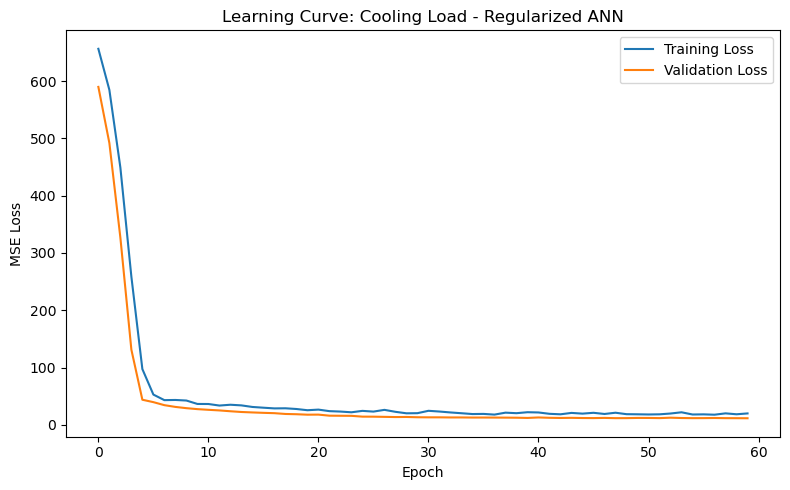

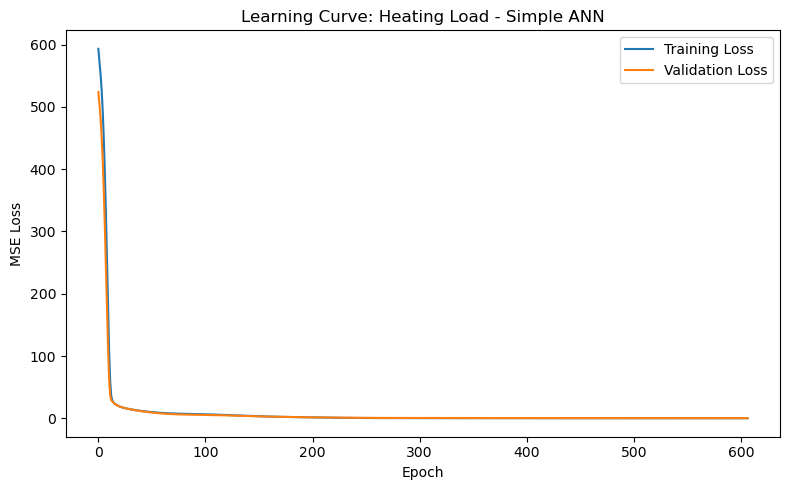

In [13]:
# ============================================================
# 13. PLOT LEARNING CURVES FOR BEST MODELS
# ============================================================

for _, row in best_dl_models.iterrows():
    key = f"{row['Target']} - {row['Model']}"
    plot_learning_curve(
        histories[key],
        title=f"Learning Curve: {key}"
    )

In [14]:
# ============================================================
# 14. ACTUAL VS PREDICTED FUNCTION
# ============================================================

def plot_actual_vs_predicted(y_true, y_pred, target_name, model_name):
    plt.figure(figsize=(6, 6))

    sns.scatterplot(
        x=y_true,
        y=y_pred
    )

    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{target_name}: Actual vs Predicted ({model_name})")
    plt.tight_layout()
    plt.show()

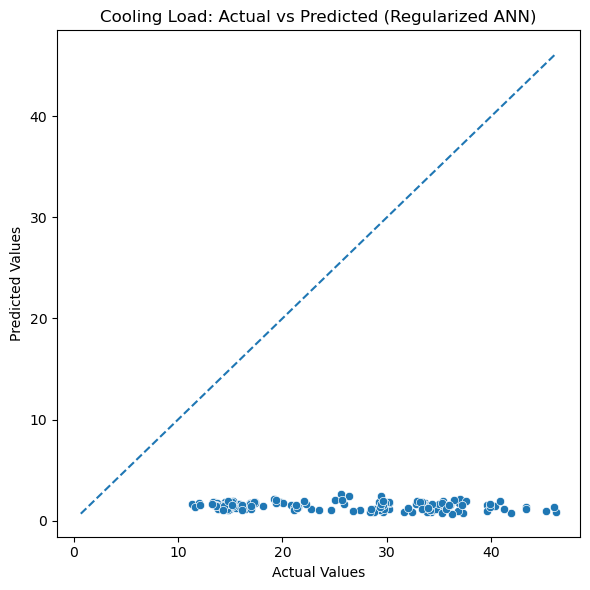

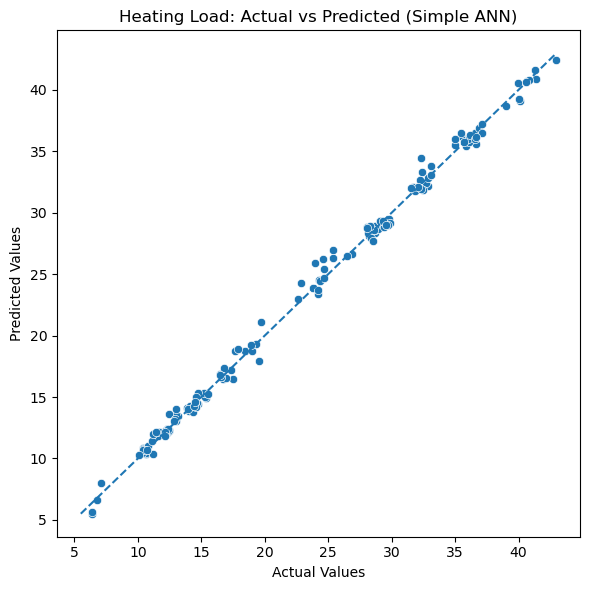

In [15]:
# ============================================================
# 15. ACTUAL VS PREDICTED FOR BEST MODELS
# ============================================================

for _, row in best_dl_models.iterrows():
    key = f"{row['Target']} - {row['Model']}"
    _, test_pred = predictions[key]

    if row["Target"] == "Heating Load":
        y_true = y_heat_test_np
    else:
        y_true = y_cool_test_np

    plot_actual_vs_predicted(
        y_true,
        test_pred,
        target_name=row["Target"],
        model_name=row["Model"]
    )

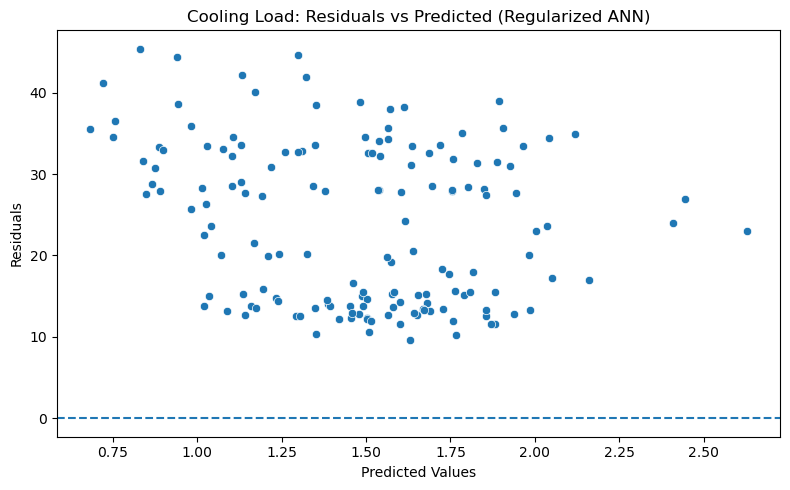

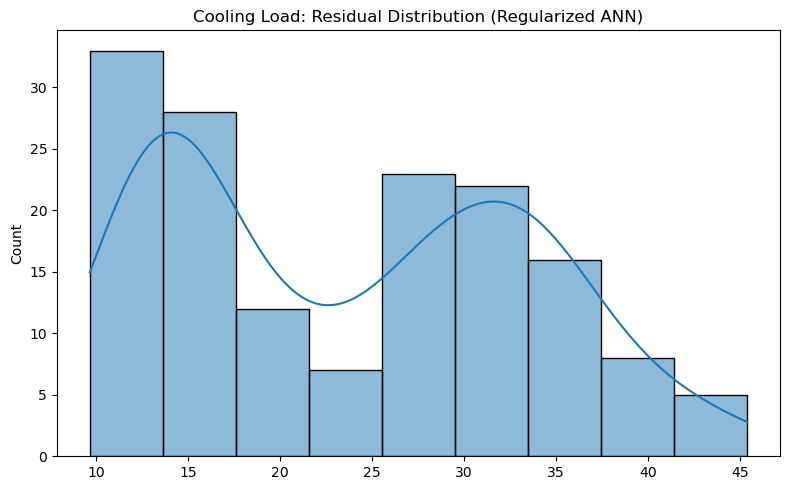

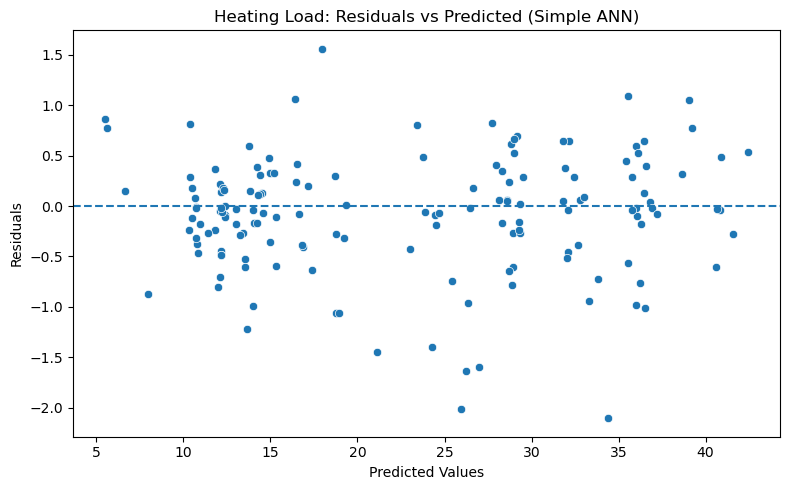

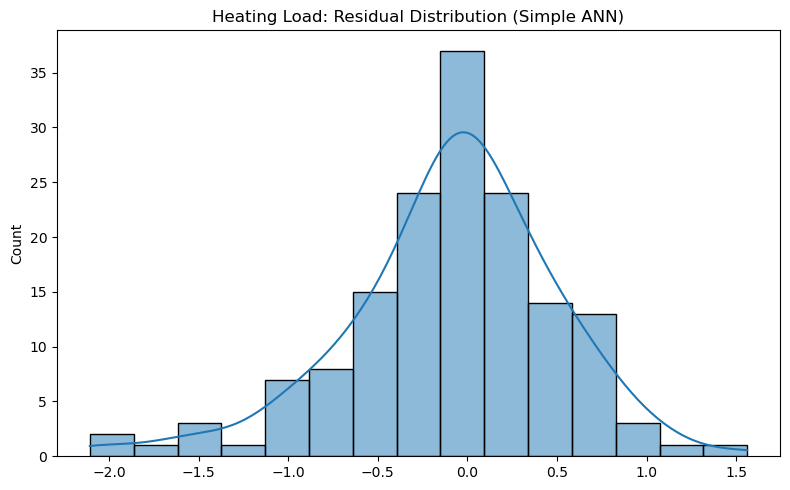

In [16]:
# ============================================================
# 16. RESIDUAL PLOTS FOR BEST MODELS
# ============================================================

def plot_residuals(y_true, y_pred, target_name, model_name):
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{target_name}: Residuals vs Predicted ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, kde=True)
    plt.title(f"{target_name}: Residual Distribution ({model_name})")
    plt.tight_layout()
    plt.show()

for _, row in best_dl_models.iterrows():
    key = f"{row['Target']} - {row['Model']}"
    _, test_pred = predictions[key]

    if row["Target"] == "Heating Load":
        y_true = y_heat_test_np
    else:
        y_true = y_cool_test_np

    plot_residuals(
        y_true,
        test_pred,
        target_name=row["Target"],
        model_name=row["Model"]
    )

# Comparison Against Best Previous Model

From the previous semi-parametric and nonlinear modeling notebook, **Tuned Gradient Boosting Regression** was the strongest model for both Heating Load and Cooling Load. The deep learning models should therefore be compared against that benchmark rather than judged in isolation.

In [17]:
# ============================================================
# 17. OPTIONAL BENCHMARK TABLE
# ============================================================

previous_best = pd.DataFrame({
    "Target": ["Heating Load", "Cooling Load"],
    "Model": ["Tuned Gradient Boosting Regression", "Tuned Gradient Boosting Regression"],
    "Train_R2": [0.999499, 0.998809],
    "Test_R2": [0.998602, 0.990551],
    "Test_Adjusted_R2": [0.998525, 0.990030],
    "Test_RMSE": [0.381722, 0.935678],
    "Test_MAE": [0.275321, 0.562829],
    "Train_Test_R2_Gap": [0.000897, 0.008258]
})

comparison_with_previous_best = pd.concat(
    [previous_best, deep_learning_results],
    ignore_index=True
).sort_values(
    ["Target", "Test_R2"],
    ascending=[True, False]
)

display(comparison_with_previous_best)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Train_Test_R2_Gap
1,Cooling Load,Tuned Gradient Boosting Regression,0.998809,0.990551,0.990030,0.935678,0.562829,0.008258
7,Cooling Load,Regularized ANN,-5.874656,-6.140565,-6.859759,25.722072,23.818806,0.265910
3,Cooling Load,Simple ANN,-5.962883,-6.243798,-6.973389,25.907340,23.920170,0.280916
5,Cooling Load,Deeper ANN,-6.321161,-6.592419,-7.357123,26.523433,24.748758,0.271258
0,Heating Load,Tuned Gradient Boosting Regression,0.999499,0.998602,0.998525,0.381722,0.275321,0.000897
2,Heating Load,Simple ANN,0.998854,0.996633,0.996294,0.592402,0.432342,0.002221
6,Heating Load,Regularized ANN,-4.449526,-4.637007,-5.204763,24.239612,21.915844,0.187480
4,Heating Load,Deeper ANN,-4.796163,-4.965566,-5.566414,24.936024,22.764751,0.169403


# Deep Learning Modeling Summary

The deep learning models provide an additional benchmark against the previous statistical, semi-parametric, and machine learning approaches. Because the dataset contains only 768 observations, deep learning is not expected to dominate tree-based ensemble methods, but it is useful for testing whether neural architectures can capture additional nonlinear structure.

The final comparison should determine whether any deep learning model improves on Tuned Gradient Boosting. If not, Tuned Gradient Boosting remains the preferred model because it achieves stronger accuracy with better interpretability and stability for small tabular datasets.

In [18]:
# ============================================================
# 18. SAVE DEEP LEARNING RESULTS
# ============================================================

OUTPUT_DIR = Path("../outputs/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

deep_learning_results.to_csv(
    OUTPUT_DIR / "deep_learning_model_results.csv",
    index=False
)

best_dl_models.to_csv(
    OUTPUT_DIR / "best_deep_learning_models.csv",
    index=False
)

comparison_with_previous_best.to_csv(
    OUTPUT_DIR / "deep_learning_vs_previous_best.csv",
    index=False
)

print("Deep learning results saved successfully.")
print("Saved to:", OUTPUT_DIR.resolve())

Deep learning results saved successfully.
Saved to: C:\Users\admin\Desktop\pppp lab\group-work\outputs\models
